See is there any bias in cell type for clones within a replicate. Just plot umap and label by clone and cell types

In [1]:
import warnings
from typing import List, Literal, Optional, Tuple

import moscot as mt
import moscot.plotting as mtp
import ot
import tqdm
from moscot.problems.time import LineageProblem, TemporalProblem

import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import euclidean_distances

import matplotlib.pyplot as plt
import pycea as py

import scanpy as sc
from anndata import AnnData
import treedata as td
from fastrna.core import fastrna_hvg, fastrna_pca

from Moslin.utility import matrixfy_character_obsm, compute_hvg_pca_fastRNA

warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FutureWarning)

ModuleNotFoundError: No module named 'Moslin'

In [ ]:
%load_ext autoreload
%autoreload 2



Early run, only **first replicate** is used. Since there are also multiple clones in the replicate, I will take the clone with the biggest lineage tree and as a result should probably subset the data before we concat. 
TODO: Figure out why there are multiple clones. Why the nodes in the tree and the clone cell count do not match up 
TODO: Create cost matrix for each time point, and the cost matrix 
TODO: Use Gene Expression for cost matrix across time points 

### Data loading and Merging


In [2]:
from pathlib import Path
basePath = "/project/imoskowitz/yubin/Lineage_Tree_Construction/"
output_data = basePath + "output_data/"
output_plot = basePath + "output_plot/"

In [19]:
Lineage_data = Path("/project/imoskowitz/kdreyer/public_datasets/005_Colgan2026/")
target_stages = ["E7.5", "E8.0", "E8.5", "E9.0"]
stage_tdatas = {stage: {} for stage in target_stages}

for file_path in Lineage_data.glob("*.h5td"):
    stem = file_path.stem
    stage = stem.split("-")[0]

    if stage in target_stages:
        stage_tdatas[stage][stem] = td.read_h5td(file_path)

# Keep the original variable name for compatibility with the rest of the notebook.
tdatas = stage_tdatas["E7.5"]

In [5]:
stage_tdatas

{'E7.5': {'E7.5-R2': TreeData object with n_obs × n_vars = 1838 × 78258
      obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree'
      var: 'gene_ids', 'mito', 'chromosome'
      obsm: 'X_scvi', 'X_umap', 'characters'
      obst: 'E7.5-R2-C1', 'E7.5-R2-C2', 'E7.5-R2-C3', 'E7.5-R2-C4', 'E7.5-R2-C5', 'E7.5-R2-C6',
  'E7.5-R1': TreeData object with n_obs × n_vars = 1342 × 78258
      obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree'
      var: 'gene_ids', 'mito', 'chromosome'
      obsm: 'X_scvi', 'X_umap', 'characters'
      obst: 'E7.5-R1-C1', 'E7.5-R1-C2',
  'E7.5-R3': TreeData object with n_obs × n_vars = 1468 × 78258
      obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate'

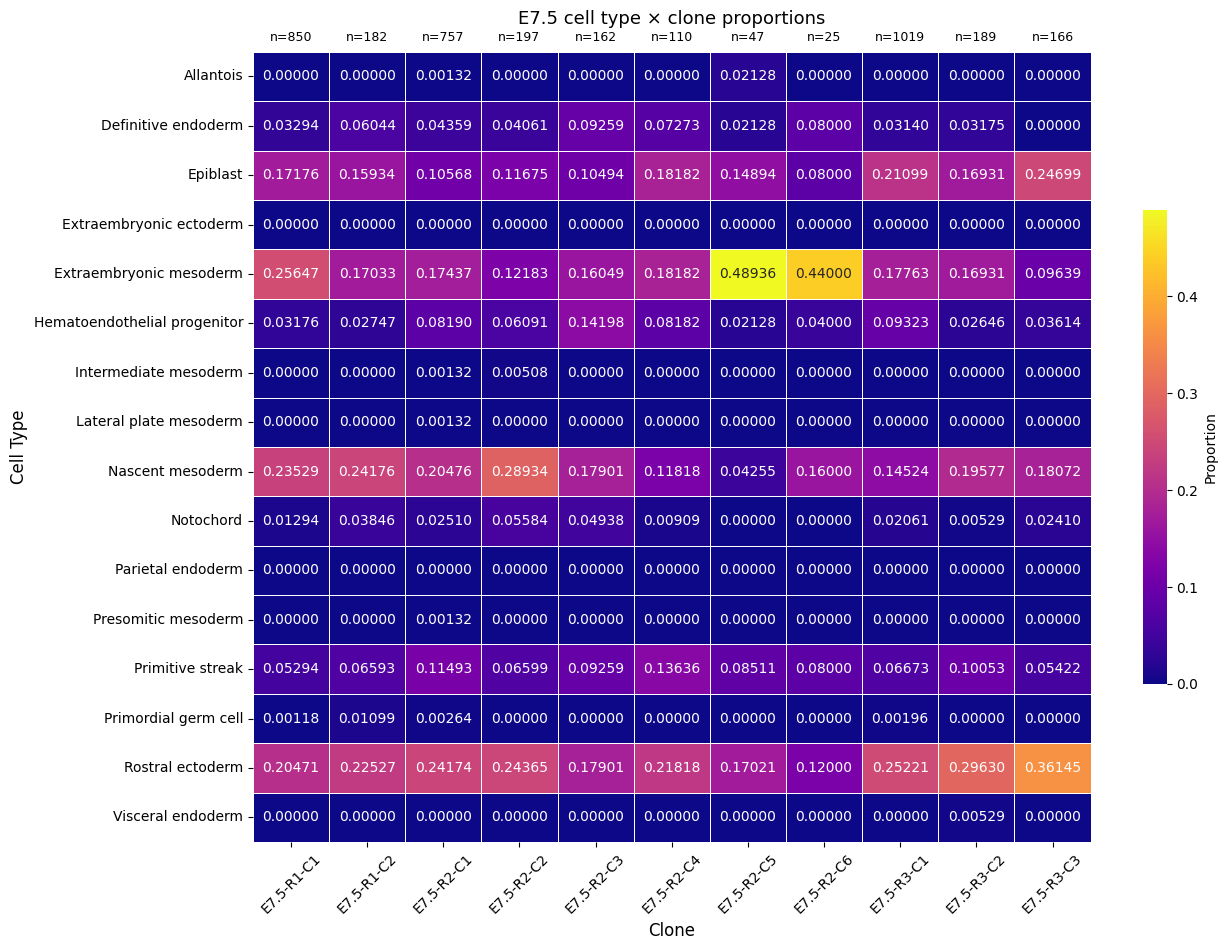

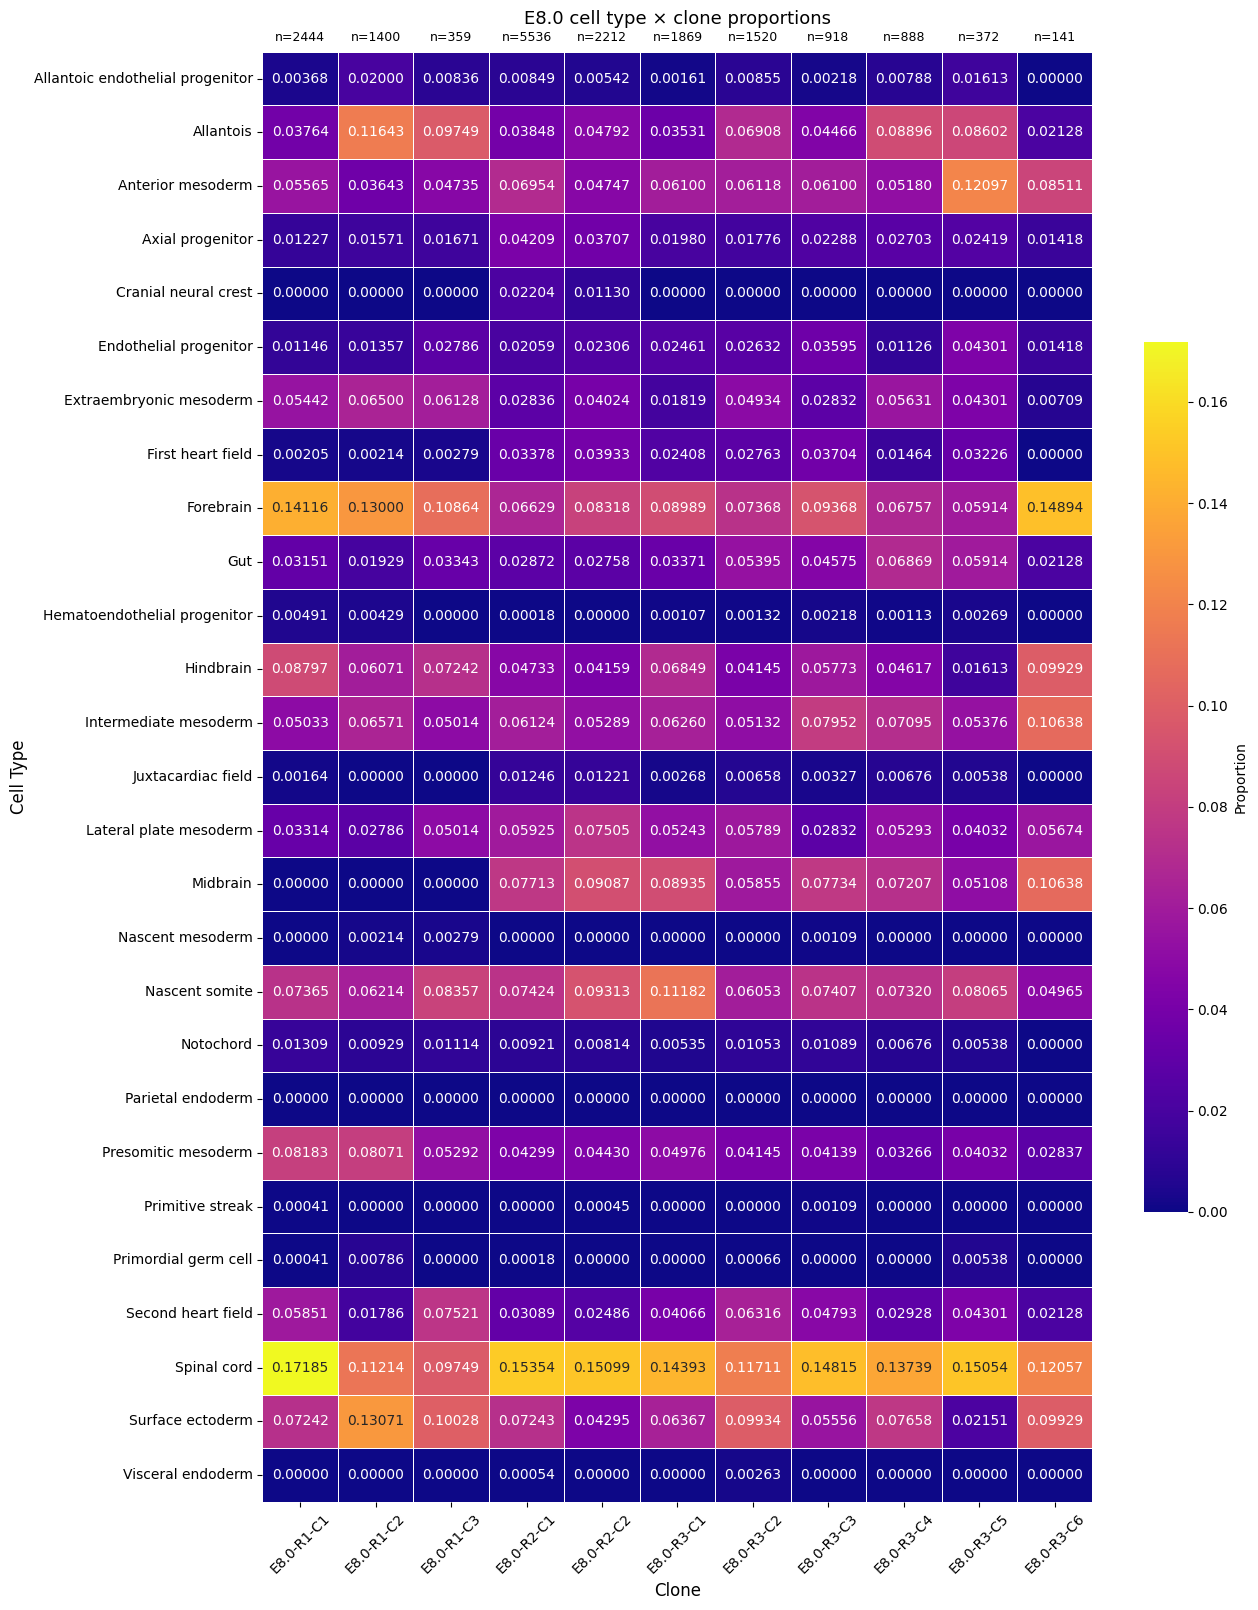

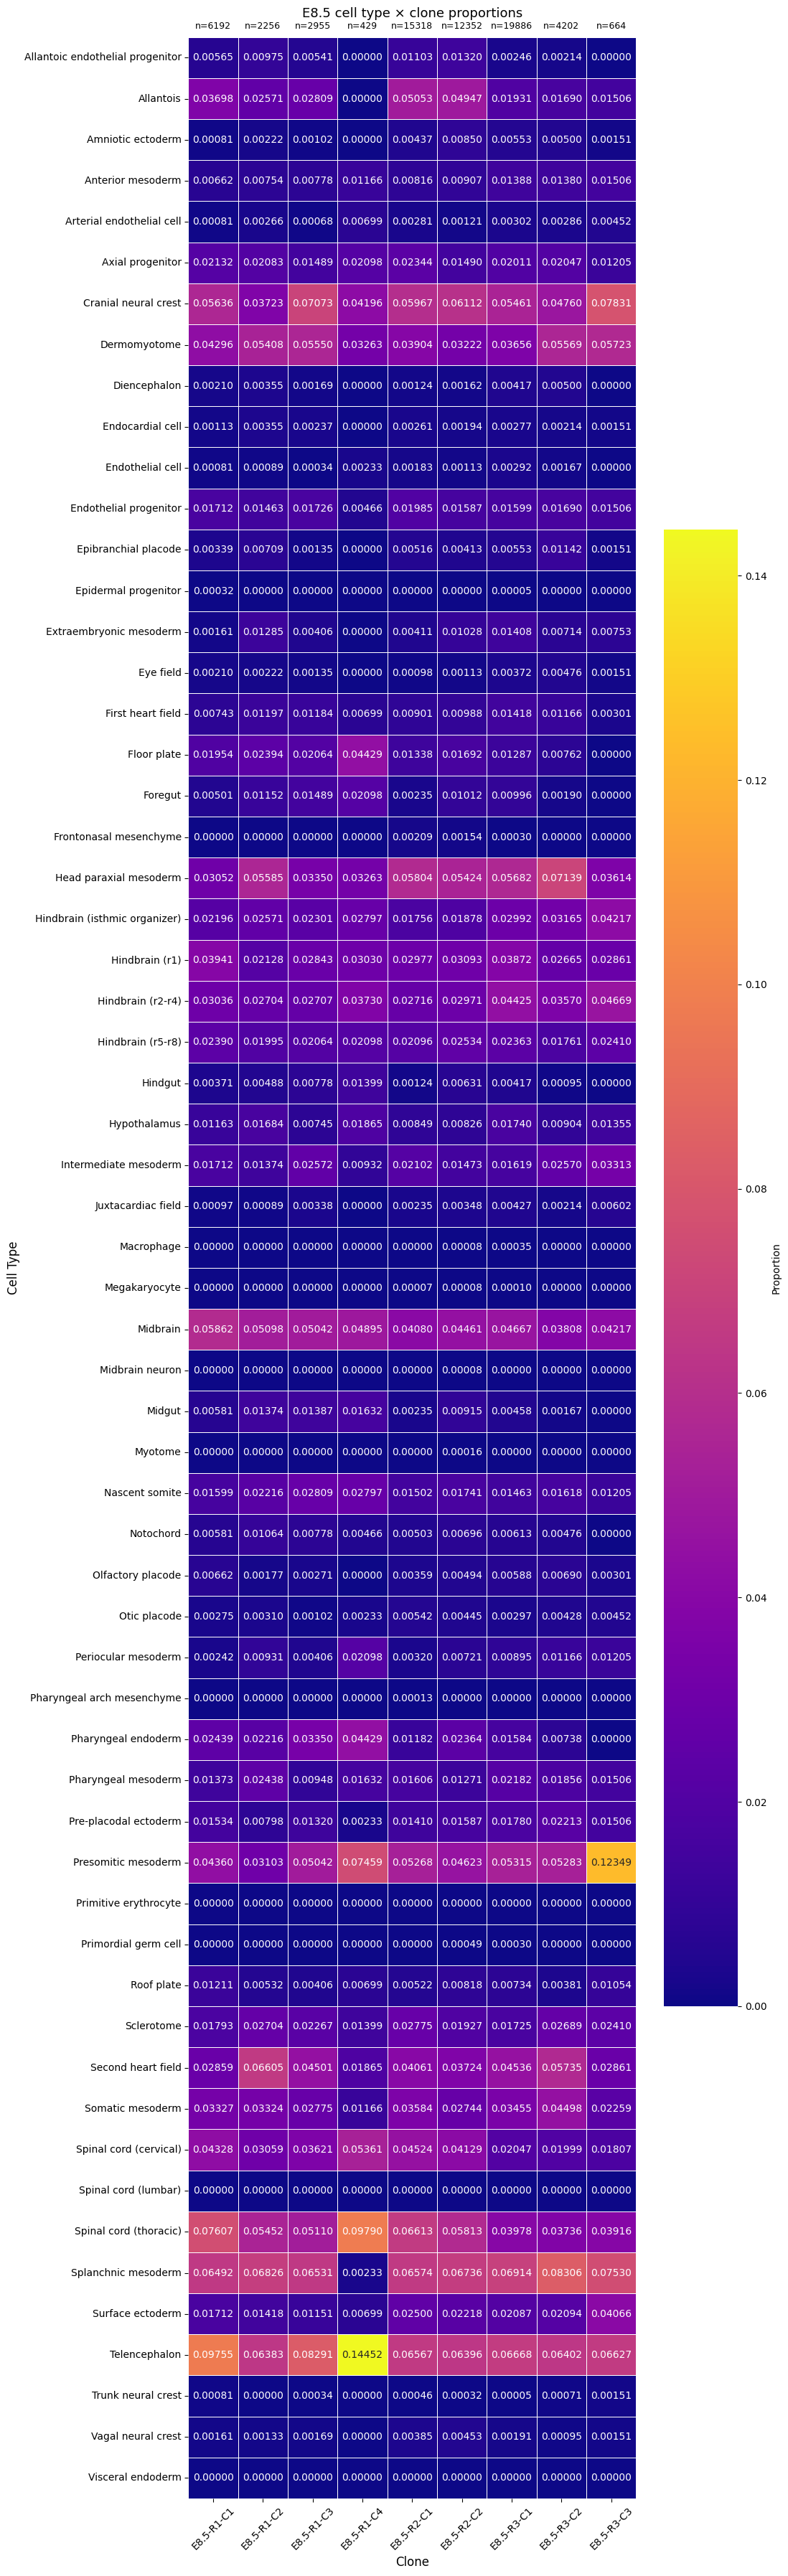

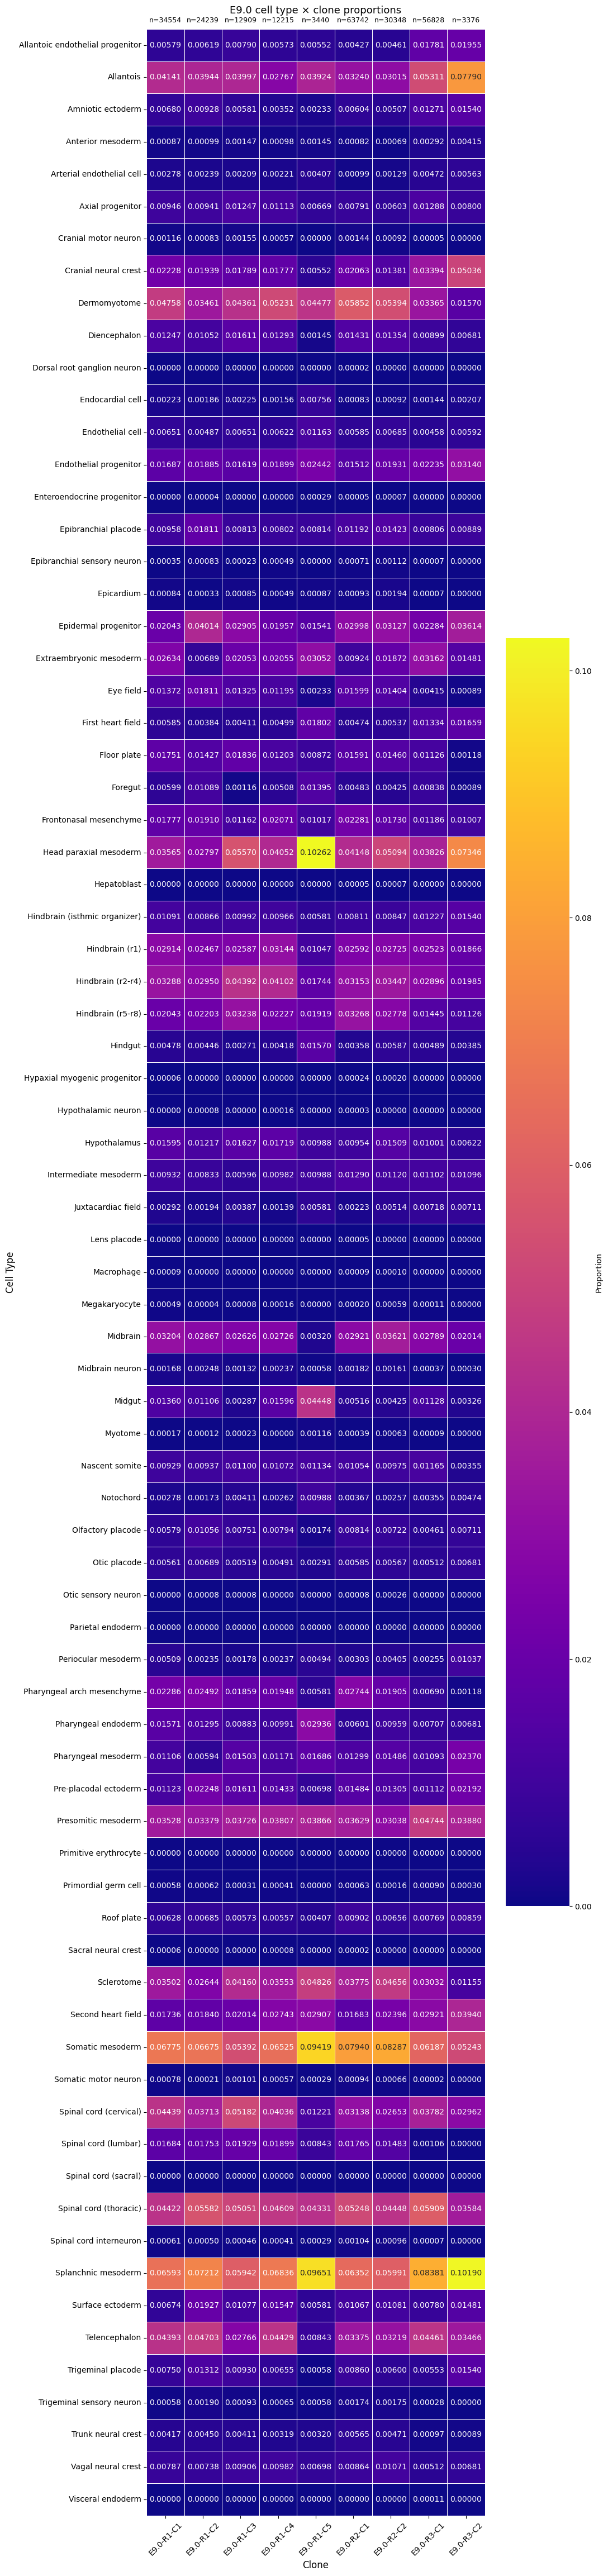

In [21]:
import seaborn as sns

stage_results = {}

for stage in target_stages:
    stage_files = stage_tdatas[stage]
    if not stage_files:
        print(f"{stage}: no files found")
        continue

    merged_tdata = td.concat(stage_files, merge='unique')
    # merged_tdata = compute_hvg_pca_fastRNA(merged_tdata, batch_key='embryo')
    # sc.pp.neighbors(merged_tdata, n_pcs=10)
    # sc.tl.umap(merged_tdata)

    # stage_results[stage] = merged_tdata
    # print(f"\n=== {stage} ===")
    # print("cells:", merged_tdata.n_obs)
    # print("genes:", merged_tdata.n_vars)

    # sc.pl.umap(merged_tdata, color=['clone', 'cell_type'], title=f"{stage} UMAP")

    counter = merged_tdata.obs.iloc[:, 0].name
    pivot_count = pd.crosstab(
        index=merged_tdata.obs["cell_type"],
        columns=merged_tdata.obs["clone"],
        values=counter,
        aggfunc="count",
        normalize="columns",
    )

    n_rows, n_cols = pivot_count.shape
    fig, ax = plt.subplots(figsize=(max(6, n_cols * 1.2), max(4, n_rows * 0.6)))
    sns.heatmap(
        pivot_count,
        ax=ax,
        cmap="plasma",
        linewidths=0.4,
        linecolor="white",
        annot=True,
        fmt=".5f",
        cbar_kws={"label": "Proportion", "shrink": 0.6},
    )

    # raw counts per clone (column totals) for the n= labels
    clone_totals = merged_tdata.obs["clone"].value_counts()

    # add n= labels above each column
    for i, clone in enumerate(pivot_count.columns):
        n = clone_totals.get(clone, 0)
        ax.text(i + 0.5, -0.15, f"n={n}", ha='center', va='bottom', fontsize=9)
    
    ax.set_ylabel("Cell Type", fontsize=12)
    ax.set_xlabel("Clone", fontsize=12)
    ax.set_title(f"{stage} cell type × clone proportions", fontsize=13, pad=20)
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)
    plt.tight_layout()
    plt.savefig("/project/imoskowitz/yubin/Lineage_Tree_Construction/output_plot/celltype_proportions/"+stage.replace(".","_")+".png")
    plt.show()

merged_tdata = next(iter(stage_results.values()), None)

By replicates instead

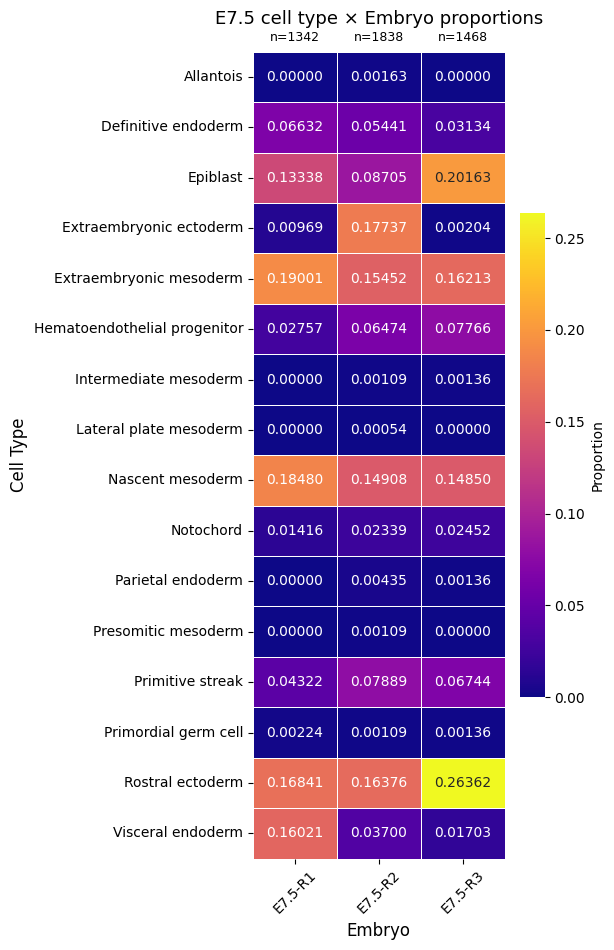

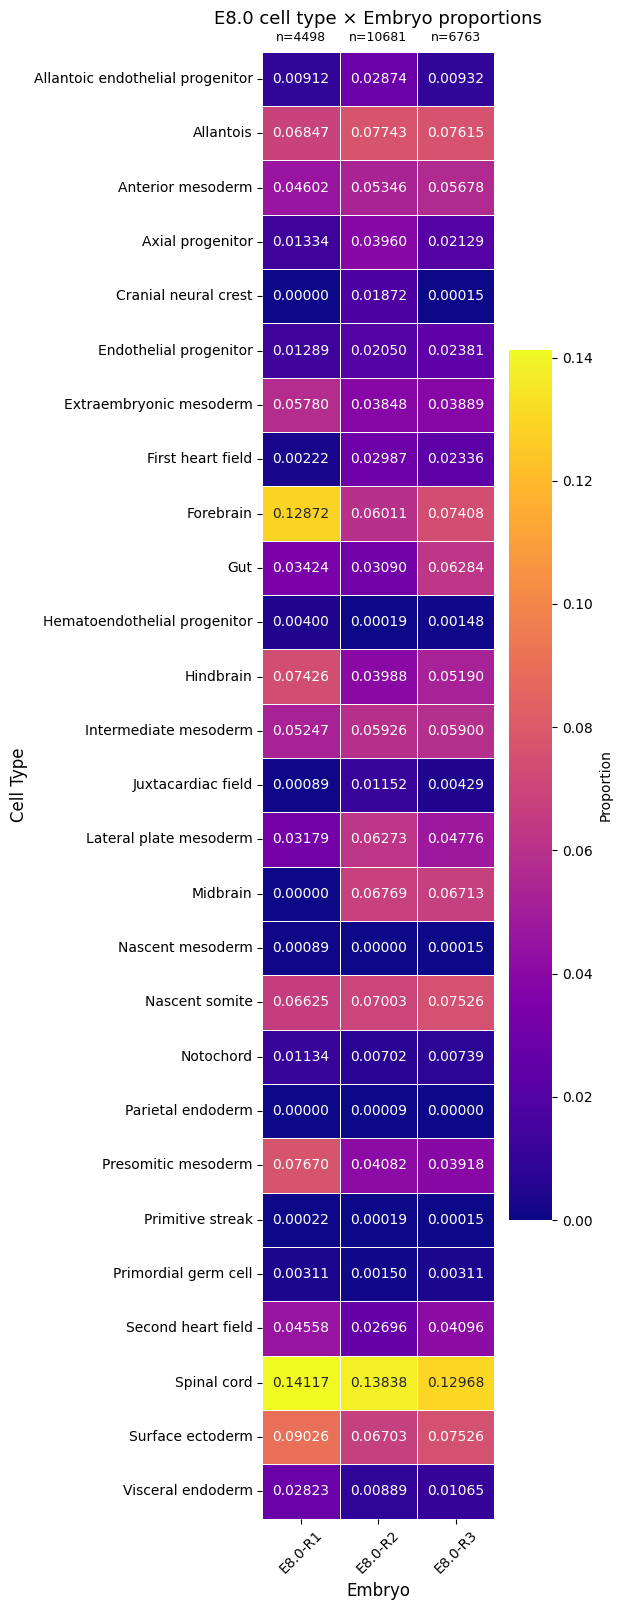

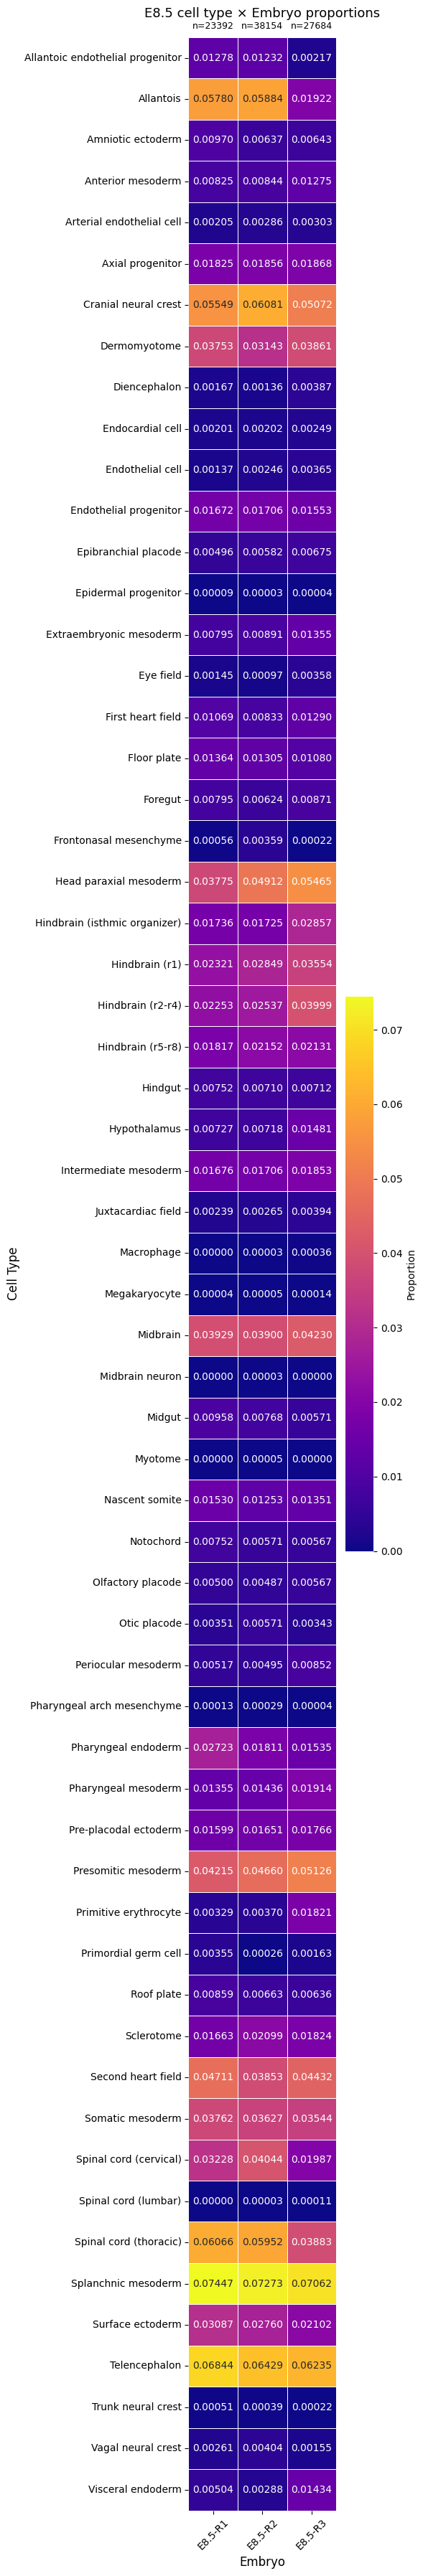

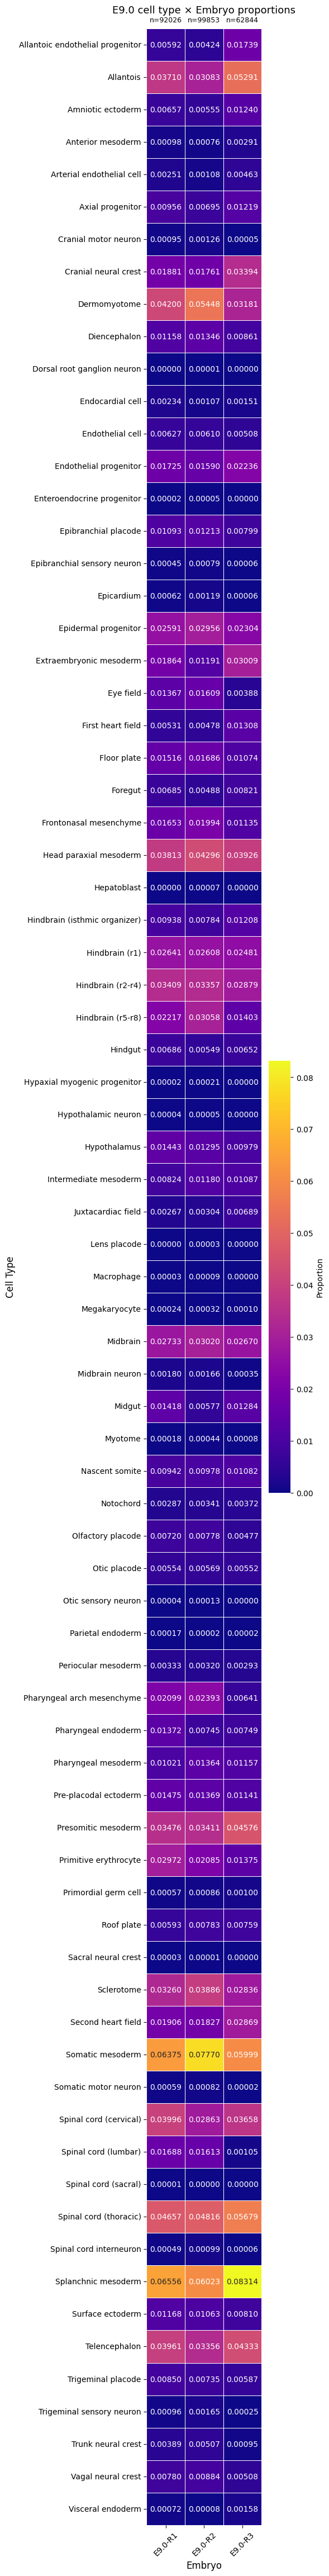

In [22]:
import seaborn as sns

stage_results = {}

for stage in target_stages:
    stage_files = stage_tdatas[stage]
    if not stage_files:
        print(f"{stage}: no files found")
        continue

    merged_tdata = td.concat(stage_files, merge='unique')
    # merged_tdata = compute_hvg_pca_fastRNA(merged_tdata, batch_key='embryo')
    # sc.pp.neighbors(merged_tdata, n_pcs=10)
    # sc.tl.umap(merged_tdata)

    # stage_results[stage] = merged_tdata
    # print(f"\n=== {stage} ===")
    # print("cells:", merged_tdata.n_obs)
    # print("genes:", merged_tdata.n_vars)

    # sc.pl.umap(merged_tdata, color=['clone', 'cell_type'], title=f"{stage} UMAP")

    counter = merged_tdata.obs.iloc[:, 0].name
    pivot_count = pd.crosstab(
        index=merged_tdata.obs["cell_type"],
        columns=merged_tdata.obs["embryo"],
        values=counter,
        aggfunc="count",
        normalize="columns",
    )

    n_rows, n_cols = pivot_count.shape
    fig, ax = plt.subplots(figsize=(max(6, n_cols * 1.2), max(4, n_rows * 0.6)))
    sns.heatmap(
        pivot_count,
        ax=ax,
        cmap="plasma",
        linewidths=0.4,
        linecolor="white",
        annot=True,
        fmt=".5f",
        cbar_kws={"label": "Proportion", "shrink": 0.6},
    )

    # raw counts per embryo (column totals) for the n= labels
    embryo_totals = merged_tdata.obs["embryo"].value_counts()

    # add n= labels above each column
    for i, embryo in enumerate(pivot_count.columns):
        n = embryo_totals.get(embryo, 0)
        ax.text(i + 0.5, -0.15, f"n={n}", ha='center', va='bottom', fontsize=9)
    
    ax.set_ylabel("Cell Type", fontsize=12)
    ax.set_xlabel("Embryo", fontsize=12)
    ax.set_title(f"{stage} cell type × Embryo proportions", fontsize=13, pad=20)
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)
    plt.tight_layout()
    plt.savefig("/project/imoskowitz/yubin/Lineage_Tree_Construction/output_plot/celltype_proportions/"+stage.replace(".","_")+"_by_embryo.png")
    plt.show()

merged_tdata = next(iter(stage_results.values()), None)

In [ ]:
merged_tdata = compute_hvg_pca_fastRNA(merged_tdata, batch_key='embryo')

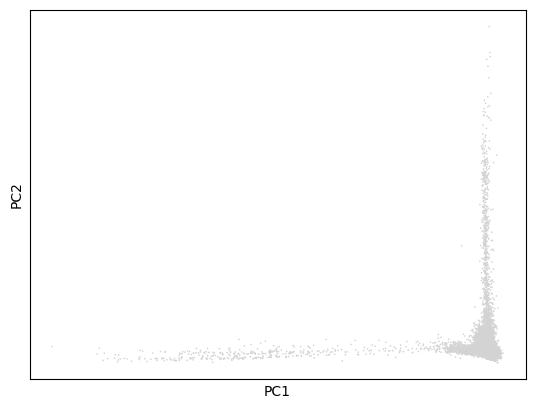

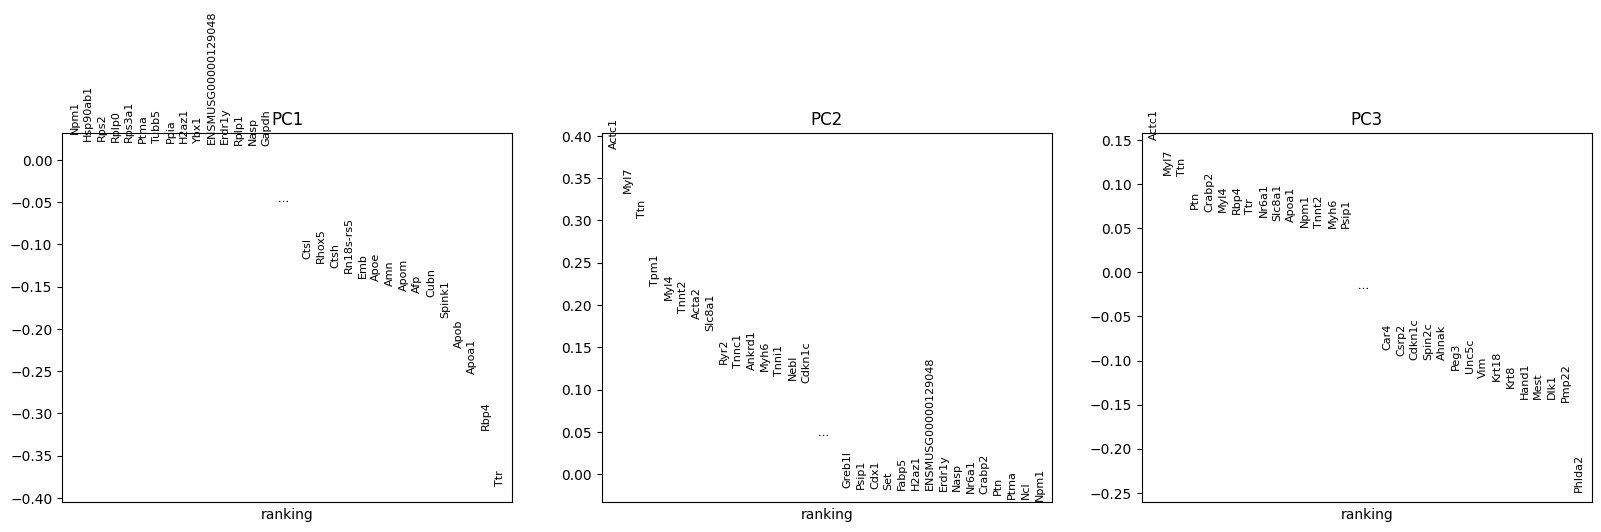

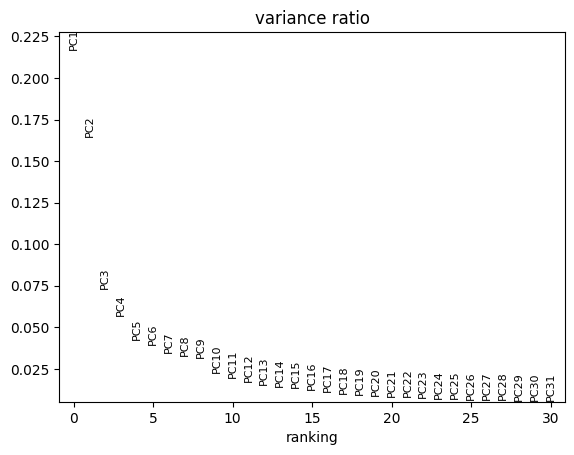

In [ ]:
sc.pl.pca_overview(merged_tdata)

In [ ]:
sc.pp.neighbors(merged_tdata, n_pcs=10)

In [ ]:
sc.tl.umap(merged_tdata)

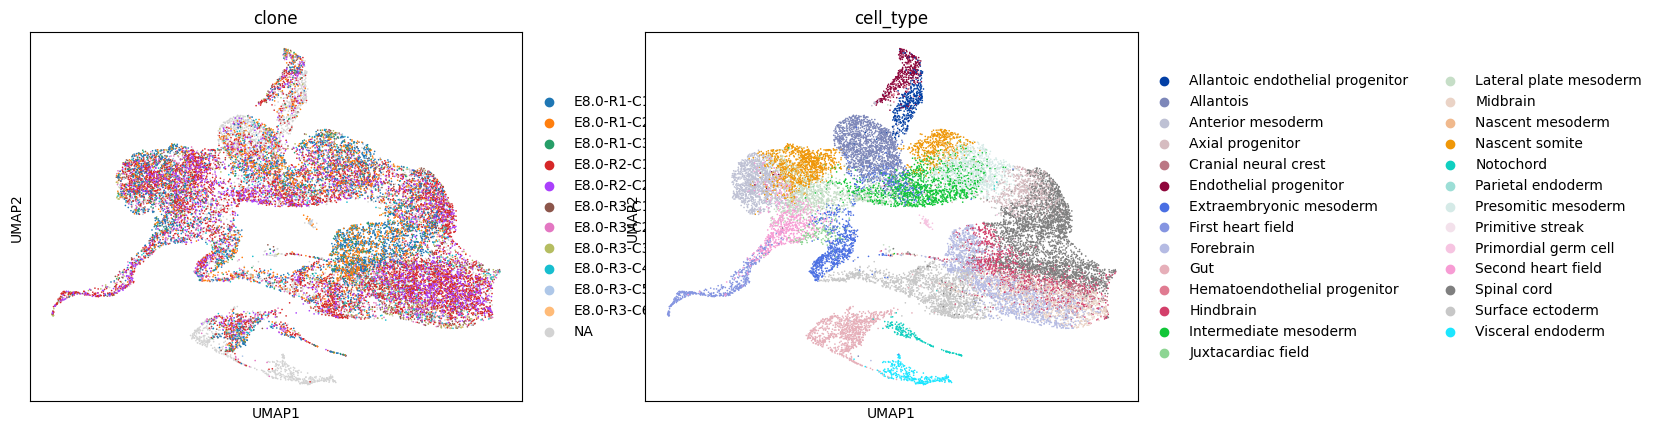

In [ ]:
sc.pl.umap(merged_tdata, color=['clone','cell_type'])

In [ ]:
counter = merged_tdata.obs.iloc[: , 0].name

pivot_count = pd.crosstab(
    index = merged_tdata.obs["cell_type"], # Celltype
    columns = merged_tdata.obs['clone'],
    values= counter, # some random observation that can be used as a counter
    aggfunc='count',
    normalize='columns'
)

In [ ]:
import seaborn as sns

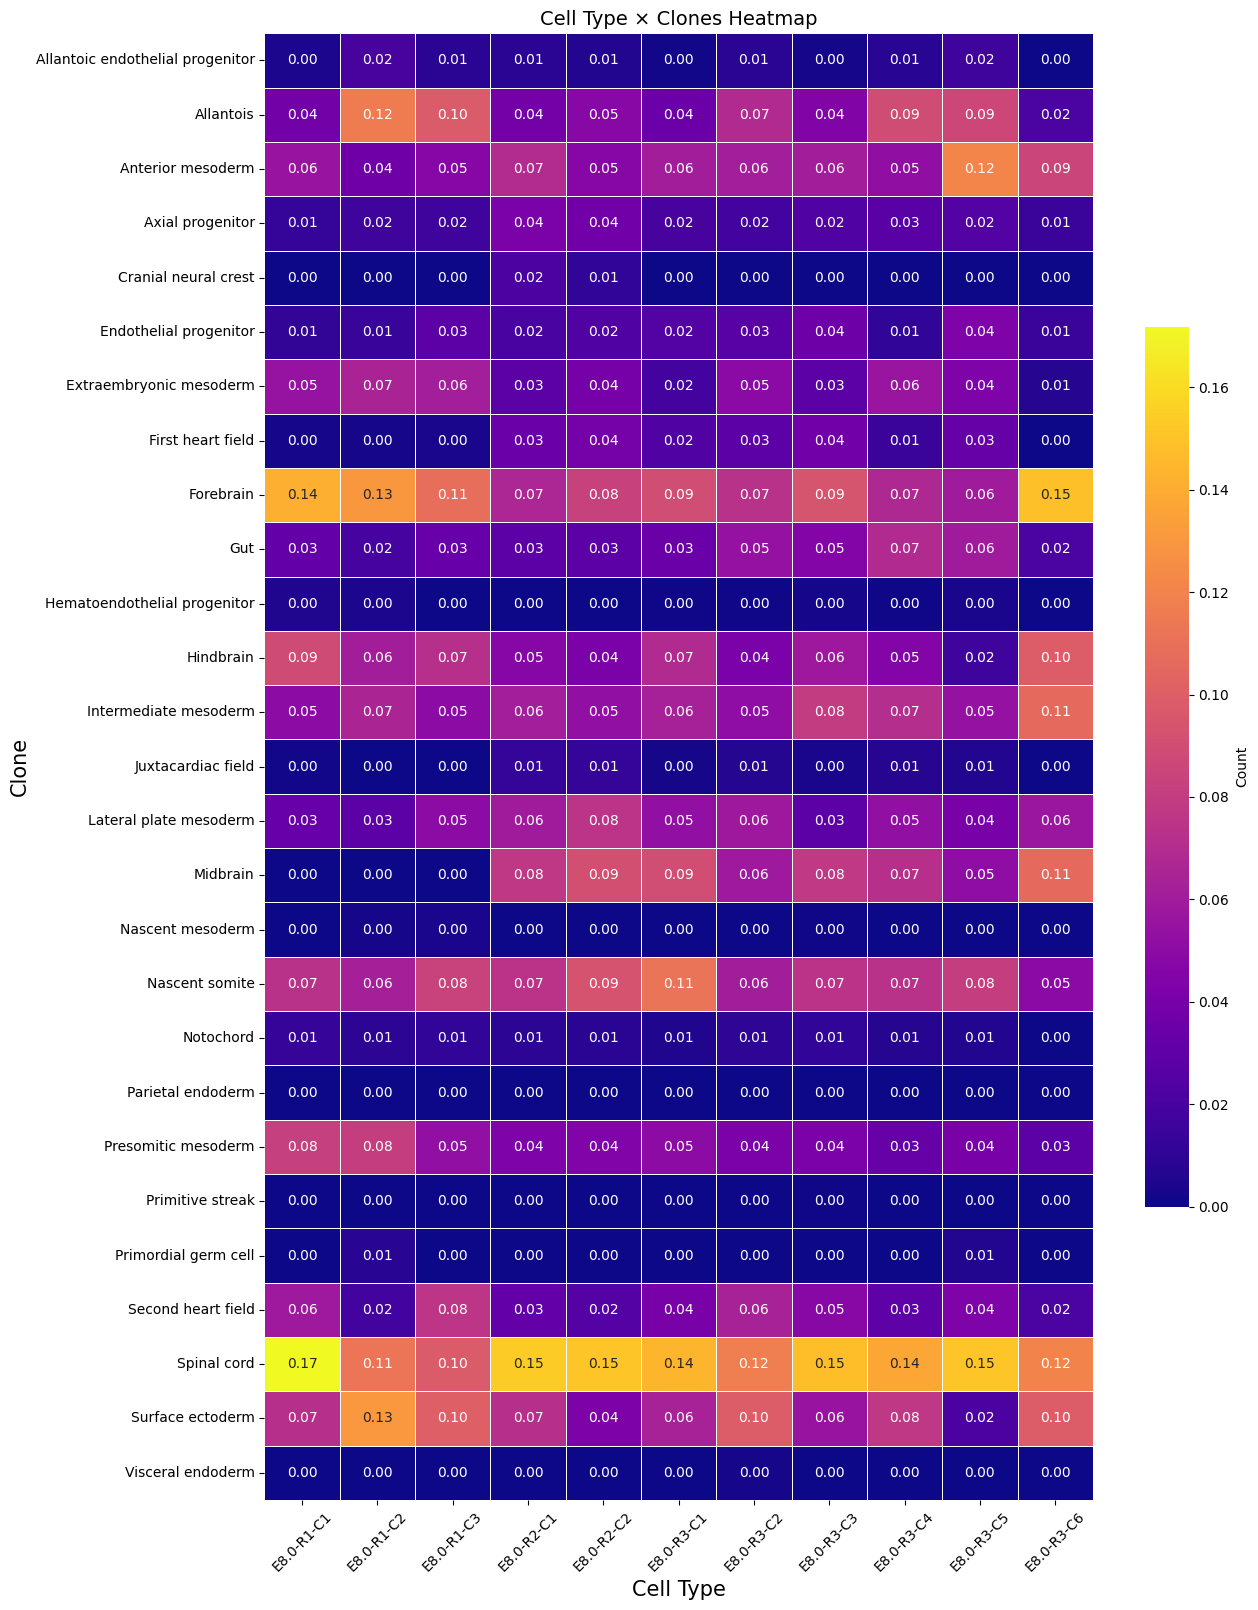

In [ ]:
n_rows, n_cols = pivot_count.shape
cell_w = 1.2   # inches per cell — increase to widen
cell_h = .6   # inches per cell — increase to tighten
fig, ax = plt.subplots(figsize=(n_cols * cell_w, n_rows * cell_h))

sns.heatmap(
    pivot_count,                  # rows = celltype, cols = leiden_1.0
    ax=ax,
    cmap="plasma",          # swap for any matplotlib colormap
    linewidths=0.4,
    linecolor="white",
    annot=True,             # show counts inside each cell
    fmt=".2f",                # integer format — use ".2f" for floats/proportions
    cbar_kws={"label": "Count", "shrink": 0.6}
)

ax.set_ylabel("Clone", fontsize=15)
ax.set_xlabel("Cell Type", fontsize=15)
ax.set_title("Cell Type × Clones Heatmap", fontsize=14)
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()